In [1]:

# ============================================================
# CELL 1: DEPENDENCY INSTALLATION - Kaggle Compatible
# Estimated time: ~3-5 minutes
# ============================================================
# Handles triton missing dependency issue on Kaggle.
# triton is NOT required for our use case (we use eager attention).

!pip install -q --upgrade transformers>=4.40.0
!pip install -q peft>=0.10.0 trl>=0.8.0
!pip install -q bitsandbytes>=0.43.0
!pip install -q datasets>=2.19.0 accelerate>=0.30.0
!pip install -q evaluate rouge_score nltk sentencepiece protobuf
!pip install -q bert_score sacrebleu
!pip install -q matplotlib seaborn scikit-learn

# Remove triton to prevent import errors on Kaggle (not needed)
!pip uninstall -y triton triton-nightly 2>/dev/null || true

print("All dependencies installed successfully!")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  DEPRECATION: Building 'rouge_score' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'rouge_score'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, 

In [2]:
# ============================================================
# CELL 2: IMPORTS & SETUP
# Estimated time: ~30 seconds
# ============================================================
import os
import gc
import json
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    GenerationConfig,
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel,
)

from datasets import load_dataset, Dataset, DatasetDict
import evaluate
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Model configuration
MODEL_NAME = "stabilityai/stable-code-3b"
MAX_SEQ_LENGTH = 512
TRAIN_SUBSET_SIZE = 5000
VAL_SUBSET_SIZE = 500
TEST_SUBSET_SIZE = 500

print(f"\nModel: {MODEL_NAME}")
print(f"Max sequence length: {MAX_SEQ_LENGTH}")
print(f"Train/Val/Test sizes: {TRAIN_SUBSET_SIZE}/{VAL_SUBSET_SIZE}/{TEST_SUBSET_SIZE}")

Device: cuda
GPU: NVIDIA RTX A5000

Model: stabilityai/stable-code-3b
Max sequence length: 512
Train/Val/Test sizes: 5000/500/500


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'code_search_net' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading CodeSearchNet dataset (Python subset)...


README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00001.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/28.7M [00:00<?, ?B/s]

python/validation-00000-of-00001.parquet:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

Dataset loaded successfully!

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 23107
    })
})

Column names: ['repository_name', 'func_path_in_r

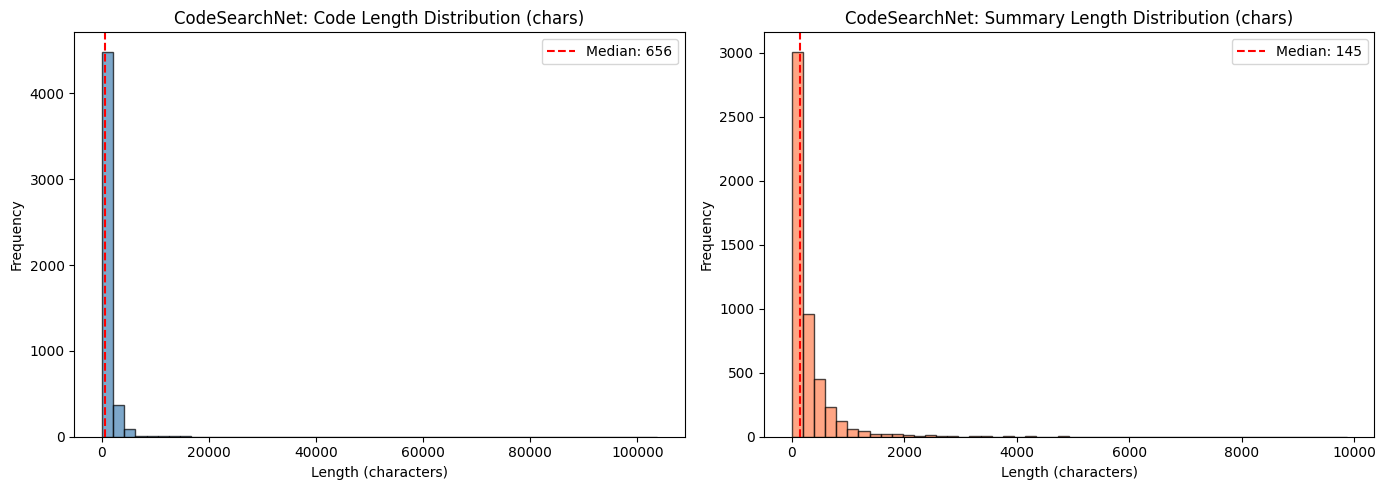

Saved: csn_data_distribution.png


In [3]:
# ============================================================
# CELL 3: LOAD & EXPLORE CodeSearchNet DATASET
# Estimated time: ~3-5 minutes
# ============================================================
print("Loading CodeSearchNet dataset (Python subset)...")
csn_dataset = load_dataset("code_search_net", "python", trust_remote_code=True)
print(f"Dataset loaded successfully!")
print(f"\nDataset structure:")
print(csn_dataset)

# Inspect column names and a sample
print(f"\nColumn names: {csn_dataset['train'].column_names}")
print(f"\nTrain size: {len(csn_dataset['train']):,}")
print(f"Validation size: {len(csn_dataset['validation']):,}")
print(f"Test size: {len(csn_dataset['test']):,}")

# Show a sample
sample = csn_dataset['train'][0]
print("\n" + "="*60)
print("SAMPLE CODE (first 500 chars):")
print("="*60)
print(sample['func_code_string'][:500])
print("\n" + "="*60)
print("SAMPLE SUMMARY:")
print("="*60)
print(sample['func_documentation_string'][:300])

# Subsample for tractable training
csn_train = csn_dataset['train'].shuffle(seed=SEED).select(range(min(TRAIN_SUBSET_SIZE, len(csn_dataset['train']))))
csn_val = csn_dataset['validation'].shuffle(seed=SEED).select(range(min(VAL_SUBSET_SIZE, len(csn_dataset['validation']))))
csn_test = csn_dataset['test'].shuffle(seed=SEED).select(range(min(TEST_SUBSET_SIZE, len(csn_dataset['test']))))

print(f"\nSubset sizes - Train: {len(csn_train)}, Val: {len(csn_val)}, Test: {len(csn_test)}")

# Distribution analysis
code_lengths = [len(x['func_code_string']) for x in csn_train]
summary_lengths = [len(x['func_documentation_string']) for x in csn_train]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(code_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('CodeSearchNet: Code Length Distribution (chars)')
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.median(code_lengths), color='red', linestyle='--', label=f'Median: {np.median(code_lengths):.0f}')
axes[0].legend()

axes[1].hist(summary_lengths, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('CodeSearchNet: Summary Length Distribution (chars)')
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.median(summary_lengths), color='red', linestyle='--', label=f'Median: {np.median(summary_lengths):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('csn_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: csn_data_distribution.png")

Loading FunCom dataset...


README.md:   0%|          | 0.00/890 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


funcom_train.tar.gz:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

funcom_val.tar.gz:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

...

Loaded FunCom from HuggingFace (apcl/funcom-java-long)

Actual columns: ['__key__', '__url__', 'txt']

Raw 'txt' sample (first 300 chars):
TDAT: 	public String register(){
		Attribute attribute = new Attribute();
		attribute.put(UserAttributeKind.EMAIL,this.email);
		attribute.put(UserAttributeKind.PASSWORD,this.password);
		attribute.put(UserAttributeKind.NICK_NAME, this.nickname);
		try {
			this.login_user = this.userService.registe


Map:   0%|          | 0/172394 [00:00<?, ? examples/s]

Map:   0%|          | 0/9196 [00:00<?, ? examples/s]

Map:   0%|          | 0/8657 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['__key__', '__url__', 'txt', 'source', 'summary'],
        num_rows: 172394
    })
    validation: Dataset({
        features: ['__key__', '__url__', 'txt', 'source', 'summary'],
        num_rows: 9196
    })
    test: Dataset({
        features: ['__key__', '__url__', 'txt', 'source', 'summary'],
        num_rows: 8657
    })
})
Available splits: ['train', 'validation', 'test']

Subset sizes - Train: 5000, Val: 500, Test: 500

SAMPLE CODE (first 500 chars):
TDAT:     public void testZoom1ActionPerformed() {
        System.out.println("testZoom1ActionPerformed");

        f.zoom1ActionPerformed(actionEvent);
 

SAMPLE SUMMARY:
	//t.zoom1ActionPerformed(actionEvent);

 		assertEquals(1,(int) f.center.getZoom());
		//assertEquals(1,(int) t.center.getZoom());
 		assertEquals(f.zoom1, f.curZoom);

    }
 COM: <s> test of zoom1 action performed method of class terp paint </s>




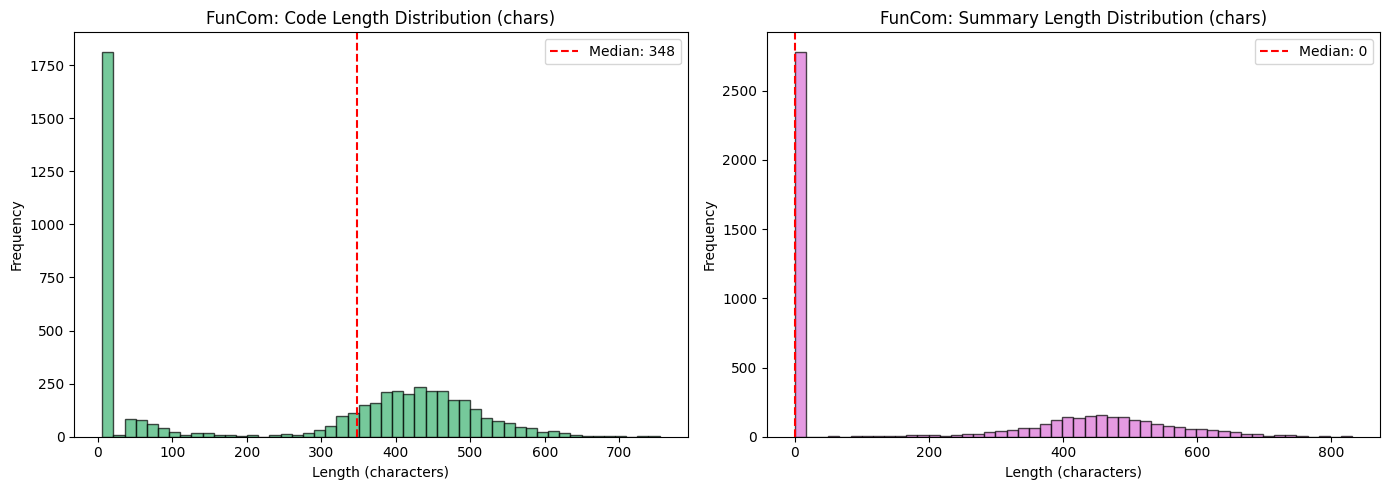

Saved: funcom_data_distribution.png


In [4]:
# ============================================================
# CELL 4: LOAD & EXPLORE FunCom DATASET
# Estimated time: ~2-3 minutes
# ============================================================
import json

print("Loading FunCom dataset...")

try:
    funcom_raw = load_dataset("apcl/funcom-java-long")  # removed trust_remote_code
    print("Loaded FunCom from HuggingFace (apcl/funcom-java-long)")
    print(f"\nActual columns: {funcom_raw['train'].column_names}")

    # The 'txt' column contains JSON or tab-separated code+summary — inspect it
    sample_txt = funcom_raw['train'][0]['txt']
    print(f"\nRaw 'txt' sample (first 300 chars):\n{sample_txt[:300]}")

    # Parse txt: FunCom long format is typically "code\tsummary" or JSON
    def parse_funcom_txt(example):
        txt = example['txt']
        try:
            parsed = json.loads(txt)
            example['source'] = parsed.get('code', parsed.get('source', txt))
            example['summary'] = parsed.get('docstring', parsed.get('summary', ''))
        except (json.JSONDecodeError, TypeError):
            # Fallback: try tab-separated
            parts = txt.split('\t', 1)
            example['source'] = parts[0] if len(parts) > 0 else txt
            example['summary'] = parts[1] if len(parts) > 1 else ''
        return example

    funcom_raw = funcom_raw.map(parse_funcom_txt)
    FUNCOM_CODE_COL = "source"
    FUNCOM_SUMMARY_COL = "summary"

except Exception as e:
    print(f"FunCom HF load failed: {e}")
    print("Falling back to CodeSearchNet Java subset as FunCom alternative...")
    funcom_raw = load_dataset("code_search_net", "java")
    FUNCOM_CODE_COL = "func_code_string"
    FUNCOM_SUMMARY_COL = "func_documentation_string"
    print("Loaded CodeSearchNet Java as FunCom alternative")

print(f"\nDataset structure:")
print(funcom_raw)

# Get available splits
available_splits = list(funcom_raw.keys())
print(f"Available splits: {available_splits}")

# Create train/val/test subsets
if 'train' in available_splits:
    funcom_full = funcom_raw['train'].shuffle(seed=SEED)
else:
    funcom_full = funcom_raw[available_splits[0]].shuffle(seed=SEED)

# Take subsets
total_needed = TRAIN_SUBSET_SIZE + VAL_SUBSET_SIZE + TEST_SUBSET_SIZE
total_available = min(len(funcom_full), total_needed)

funcom_train = funcom_full.select(range(min(TRAIN_SUBSET_SIZE, total_available)))
offset = len(funcom_train)
funcom_val = funcom_full.select(range(offset, min(offset + VAL_SUBSET_SIZE, len(funcom_full))))
offset += len(funcom_val)
funcom_test = funcom_full.select(range(offset, min(offset + TEST_SUBSET_SIZE, len(funcom_full))))

print(f"\nSubset sizes - Train: {len(funcom_train)}, Val: {len(funcom_val)}, Test: {len(funcom_test)}")

# Show sample
sample_fc = funcom_train[0]
print("\n" + "="*60)
print("SAMPLE CODE (first 500 chars):")
print("="*60)
print(str(sample_fc[FUNCOM_CODE_COL])[:500])
print("\n" + "="*60)
print("SAMPLE SUMMARY:")
print("="*60)
print(str(sample_fc[FUNCOM_SUMMARY_COL])[:300])

# Distribution analysis
fc_code_lengths = [len(str(x[FUNCOM_CODE_COL])) for x in funcom_train]
fc_summary_lengths = [len(str(x[FUNCOM_SUMMARY_COL])) for x in funcom_train]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(fc_code_lengths, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0].set_title('FunCom: Code Length Distribution (chars)')
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.median(fc_code_lengths), color='red', linestyle='--', label=f'Median: {np.median(fc_code_lengths):.0f}')
axes[0].legend()

axes[1].hist(fc_summary_lengths, bins=50, color='orchid', edgecolor='black', alpha=0.7)
axes[1].set_title('FunCom: Summary Length Distribution (chars)')
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.median(fc_summary_lengths), color='red', linestyle='--', label=f'Median: {np.median(fc_summary_lengths):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('funcom_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: funcom_data_distribution.png")

In [9]:
# ============================================================
# CELL 5: TOKENIZER SETUP & DATA PREPROCESSING
# Estimated time: ~5-8 minutes (both datasets)
# ============================================================
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Set pad token (GPT-style models often lack one)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token: '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")
print(f"PAD token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")

# ---- Prompt formatting ----
PROMPT_TEMPLATE = """Below is a code snippet. Write a concise summary of what the code does.

### Code:
{code}

### Summary:
{summary}"""

def format_prompt(code, summary=""):
    """Format a code-summary pair into the prompt template."""
    return PROMPT_TEMPLATE.format(code=code.strip(), summary=summary.strip())

def format_prompt_for_inference(code):
    """Format code for inference (no summary, model generates it)."""
    return f"""Below is a code snippet. Write a concise summary of what the code does.

### Code:
{code.strip()}

### Summary:
"""

# ---- Tokenization functions ----
def tokenize_function(examples, code_col, summary_col):
    """
    Tokenize code-summary pairs with proper label masking.
    The loss is only computed on the summary tokens.
    """
    all_input_ids = []
    all_attention_masks = []
    all_labels = []

    for code, summary in zip(examples[code_col], examples[summary_col]):
        code = str(code).strip()
        summary = str(summary).strip()

        # Truncate very long code to leave room for summary
        if len(code) > 1500:
            code = code[:1500]
        if len(summary) > 300:
            summary = summary[:300]

        # Tokenize the prompt part (code + instruction)
        prompt = format_prompt_for_inference(code)
        prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

        # Tokenize the summary part
        summary_with_eos = summary + tokenizer.eos_token
        summary_ids = tokenizer.encode(summary_with_eos, add_special_tokens=False)

        # Combine
        input_ids = prompt_ids + summary_ids

        # Truncate to max length
        if len(input_ids) > MAX_SEQ_LENGTH:
            input_ids = input_ids[:MAX_SEQ_LENGTH]

        attention_mask = [1] * len(input_ids)

        labels = [-100] * len(prompt_ids) + summary_ids
        if len(labels) > MAX_SEQ_LENGTH:
            labels = labels[:MAX_SEQ_LENGTH]
        
        # Add this check:
        if all(l == -100 for l in labels):
            # Prompt too long — truncate prompt to leave room for summary
            allowed_prompt = MAX_SEQ_LENGTH - len(summary_ids)
            prompt_ids = prompt_ids[:allowed_prompt]
            input_ids = prompt_ids + summary_ids
            labels = [-100] * len(prompt_ids) + summary_ids

        # Pad to max length
        padding_length = MAX_SEQ_LENGTH - len(input_ids)
        input_ids = input_ids + [tokenizer.pad_token_id] * padding_length
        attention_mask = attention_mask + [0] * padding_length
        labels = labels + [-100] * padding_length

        all_input_ids.append(input_ids)
        all_attention_masks.append(attention_mask)
        all_labels.append(labels)

    return {
        "input_ids": all_input_ids,
        "attention_mask": all_attention_masks,
        "labels": all_labels,
    }

# ---- Tokenize CodeSearchNet ----
print("\nTokenizing CodeSearchNet dataset...")
csn_train_tok = csn_train.map(
    lambda x: tokenize_function(x, "func_code_string", "func_documentation_string"),
    batched=True,
    batch_size=256,
    remove_columns=csn_train.column_names,
    desc="Tokenizing CSN train",
)
csn_val_tok = csn_val.map(
    lambda x: tokenize_function(x, "func_code_string", "func_documentation_string"),
    batched=True,
    batch_size=256,
    remove_columns=csn_val.column_names,
    desc="Tokenizing CSN val",
)
csn_test_tok = csn_test.map(
    lambda x: tokenize_function(x, "func_code_string", "func_documentation_string"),
    batched=True,
    batch_size=256,
    remove_columns=csn_test.column_names,
    desc="Tokenizing CSN test",
)

csn_train_tok.set_format("torch")
csn_val_tok.set_format("torch")
csn_test_tok.set_format("torch")

print(f"CSN Tokenized - Train: {len(csn_train_tok)}, Val: {len(csn_val_tok)}, Test: {len(csn_test_tok)}")

# ---- Tokenize FunCom ----
print("\nTokenizing FunCom dataset...")
fc_train_tok = funcom_train.map(
    lambda x: tokenize_function(x, FUNCOM_CODE_COL, FUNCOM_SUMMARY_COL),
    batched=True,
    batch_size=256,
    remove_columns=funcom_train.column_names,
    desc="Tokenizing FunCom train",
)
fc_val_tok = funcom_val.map(
    lambda x: tokenize_function(x, FUNCOM_CODE_COL, FUNCOM_SUMMARY_COL),
    batched=True,
    batch_size=256,
    remove_columns=funcom_val.column_names,
    desc="Tokenizing FunCom val",
)
fc_test_tok = funcom_test.map(
    lambda x: tokenize_function(x, FUNCOM_CODE_COL, FUNCOM_SUMMARY_COL),
    batched=True,
    batch_size=256,
    remove_columns=funcom_test.column_names,
    desc="Tokenizing FunCom test",
)

fc_train_tok.set_format("torch")
fc_val_tok.set_format("torch")
fc_test_tok.set_format("torch")

print(f"FunCom Tokenized - Train: {len(fc_train_tok)}, Val: {len(fc_val_tok)}, Test: {len(fc_test_tok)}")

# Show tokenization stats
sample_ids = csn_train_tok[0]['input_ids']
non_pad = (sample_ids != tokenizer.pad_token_id).sum().item()
print(f"\nSample token length (non-pad): {non_pad}/{MAX_SEQ_LENGTH}")
print("Tokenization complete!")

Loading tokenizer...
Vocab size: 50254
EOS token: '<|endoftext|>' (id=0)
PAD token: '<|padding|>' (id=1)

Tokenizing CodeSearchNet dataset...


Tokenizing CSN train:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing CSN val:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing CSN test:   0%|          | 0/500 [00:00<?, ? examples/s]

CSN Tokenized - Train: 5000, Val: 500, Test: 500

Tokenizing FunCom dataset...


Tokenizing FunCom train:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing FunCom val:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing FunCom test:   0%|          | 0/500 [00:00<?, ? examples/s]

FunCom Tokenized - Train: 5000, Val: 500, Test: 500

Sample token length (non-pad): 386/512
Tokenization complete!


In [10]:
# ============================================================
# CELL 6: LOAD MODEL WITH QLoRA
# Estimated time: ~3-5 minutes
# ============================================================

# 4-bit quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading model with 4-bit quantization...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",  # Avoid flash_attn/triton dependency
)

# Prepare model for k-bit training
model = prepare_model_for_kbit_training(model)
model.config.use_cache = False  # Disable KV cache for training

# LoRA configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

# Apply LoRA
model = get_peft_model(model, lora_config)

# Print parameter counts
trainable, total = model.get_nb_trainable_parameters()
print(f"\nModel loaded successfully!")
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Trainable %: {100 * trainable / total:.2f}%")
print(f"Memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")

# Model architecture overview
print(f"\nModel architecture:")
print(f"  Layers: {model.config.num_hidden_layers}")
print(f"  Hidden size: {model.config.hidden_size}")
print(f"  Attention heads: {model.config.num_attention_heads}")
print(f"  Vocab size: {model.config.vocab_size}")

Loading model with 4-bit quantization...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]


Model loaded successfully!
Total parameters: 2,820,477,952
Trainable parameters: 25,034,752
Trainable %: 0.89%
Memory footprint: 2.40 GB

Model architecture:
  Layers: 32
  Hidden size: 2560
  Attention heads: 32
  Vocab size: 50304


In [11]:
# ============================================================
# CELL 7: FINE-TUNE ON CodeSearchNet
# Estimated time: ~30-45 minutes
# ============================================================
from transformers import EarlyStoppingCallback

CSN_OUTPUT_DIR = "./results_csn"

csn_training_args = TrainingArguments(
    output_dir=CSN_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.01,
    optim="paged_adamw_8bit",
    fp16=True,
    bf16=False,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
    gradient_checkpointing=True,
    max_grad_norm=0.3,
    # group_by_length=True,
)

csn_trainer = Trainer(
    model=model,
    args=csn_training_args,
    train_dataset=csn_train_tok,
    eval_dataset=csn_val_tok,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Starting fine-tuning on CodeSearchNet...")
print(f"Total training steps: ~{len(csn_train_tok) // (4 * 4) * 3}")
csn_train_result = csn_trainer.train()

print("\n" + "="*50)
print("CodeSearchNet Training Complete!")
print(f"Training loss: {csn_train_result.training_loss:.4f}")
print(f"Training time: {csn_train_result.metrics['train_runtime']:.1f}s")

# Save the model
csn_trainer.save_model(f"{CSN_OUTPUT_DIR}/final_model")
print(f"Model saved to {CSN_OUTPUT_DIR}/final_model")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting fine-tuning on CodeSearchNet...
Total training steps: ~936


Step,Training Loss,Validation Loss
100,0.054235,0.052099
200,0.032159,0.039611
300,0.035603,0.034845
400,0.024442,0.035177
500,0.018033,0.036458
600,0.025577,0.033053
700,0.014924,0.034416
800,0.008741,0.038425
900,0.007931,0.036261



CodeSearchNet Training Complete!
Training loss: 0.0297
Training time: 5118.2s
Model saved to ./results_csn/final_model


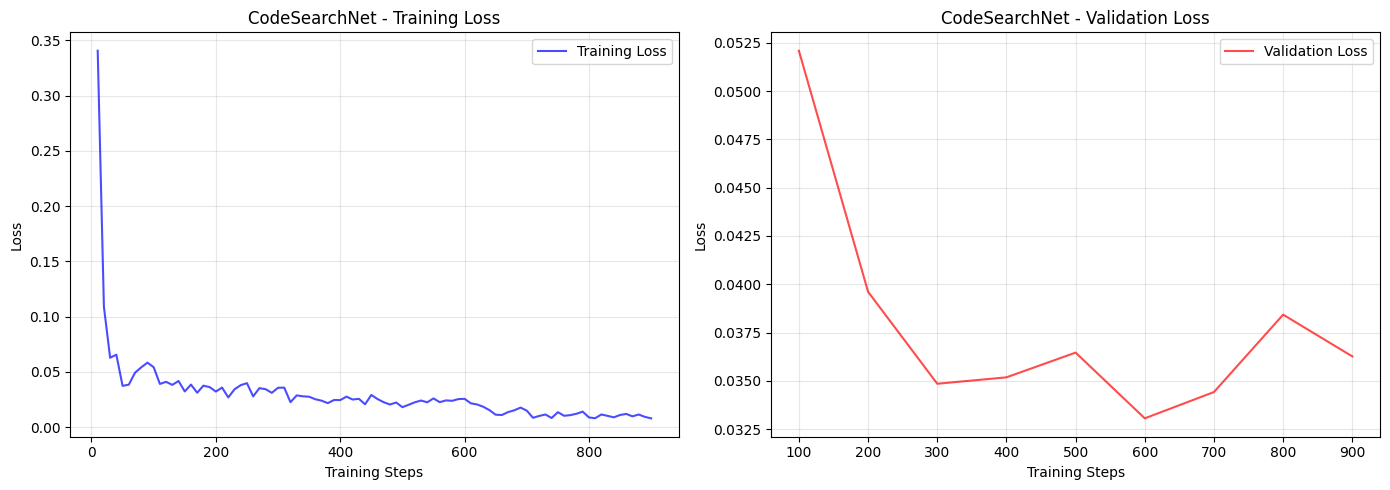

Saved: csn_training_curves.png

Best validation loss: 0.0331
Final validation loss: 0.0363


In [12]:
# ============================================================
# CELL 8: PLOT CodeSearchNet TRAINING CURVES
# Estimated time: ~10 seconds
# ============================================================
# Extract training logs
csn_log_history = csn_trainer.state.log_history

csn_train_losses = [(x['step'], x['loss']) for x in csn_log_history if 'loss' in x]
csn_eval_losses = [(x['step'], x['eval_loss']) for x in csn_log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
if csn_train_losses:
    steps, losses = zip(*csn_train_losses)
    axes[0].plot(steps, losses, 'b-', alpha=0.7, linewidth=1.5, label='Training Loss')
    axes[0].set_title('CodeSearchNet - Training Loss')
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Validation loss
if csn_eval_losses:
    steps, losses = zip(*csn_eval_losses)
    axes[1].plot(steps, losses, 'r-', alpha=0.7, linewidth=1.5, label='Validation Loss')
    axes[1].set_title('CodeSearchNet - Validation Loss')
    axes[1].set_xlabel('Training Steps')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('csn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: csn_training_curves.png")

# Print final metrics
if csn_eval_losses:
    print(f"\nBest validation loss: {min(l for _, l in csn_eval_losses):.4f}")
    print(f"Final validation loss: {csn_eval_losses[-1][1]:.4f}")

In [13]:
# ============================================================
# CELL 9: RELOAD MODEL & FINE-TUNE ON FunCom
# Estimated time: ~35-50 minutes (includes model reload)
# ============================================================

# Free memory from CSN training
del csn_trainer
gc.collect()
torch.cuda.empty_cache()

# Reload the base model with fresh LoRA adapters
print("Reloading model with fresh LoRA adapters for FunCom training...")
model_fc = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
model_fc = prepare_model_for_kbit_training(model_fc)
model_fc.config.use_cache = False
model_fc = get_peft_model(model_fc, lora_config)

trainable, total = model_fc.get_nb_trainable_parameters()
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

FC_OUTPUT_DIR = "./results_funcom"

fc_training_args = TrainingArguments(
    output_dir=FC_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.01,
    optim="paged_adamw_8bit",
    fp16=True,
    bf16=False,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
    gradient_checkpointing=True,
    max_grad_norm=0.3,
    # group_by_length=True,
)

fc_trainer = Trainer(
    model=model_fc,
    args=fc_training_args,
    train_dataset=fc_train_tok,
    eval_dataset=fc_val_tok,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("\nStarting fine-tuning on FunCom...")
print(f"Total training steps: ~{len(fc_train_tok) // (4 * 4) * 3}")
fc_train_result = fc_trainer.train()

print("\n" + "="*50)
print("FunCom Training Complete!")
print(f"Training loss: {fc_train_result.training_loss:.4f}")
print(f"Training time: {fc_train_result.metrics['train_runtime']:.1f}s")

# Save the model
fc_trainer.save_model(f"{FC_OUTPUT_DIR}/final_model")
print(f"Model saved to {FC_OUTPUT_DIR}/final_model")

Reloading model with fresh LoRA adapters for FunCom training...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainable parameters: 25,034,752 / 2,820,477,952 (0.89%)

Starting fine-tuning on FunCom...
Total training steps: ~936


Step,Training Loss,Validation Loss
100,1.277251,1.195675
200,1.243189,1.183868
300,1.215569,1.182375
400,0.915270,1.228855
500,0.919799,1.215172
600,0.973610,1.217872



FunCom Training Complete!
Training loss: 1.1284
Training time: 3404.0s
Model saved to ./results_funcom/final_model


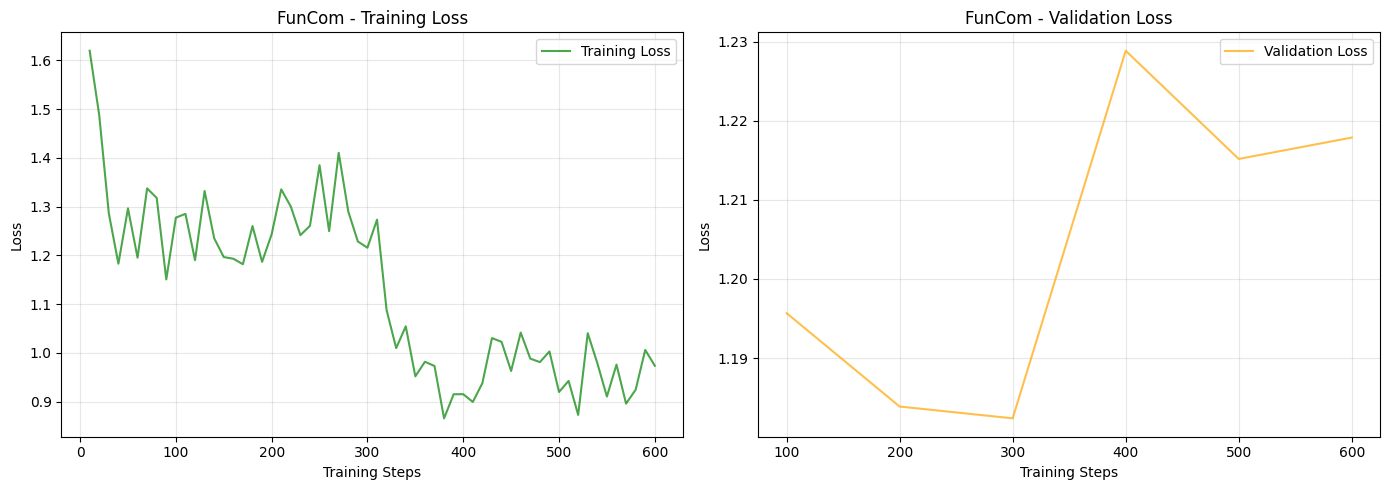

Saved: funcom_training_curves.png

Best validation loss: 1.1824
Final validation loss: 1.2179


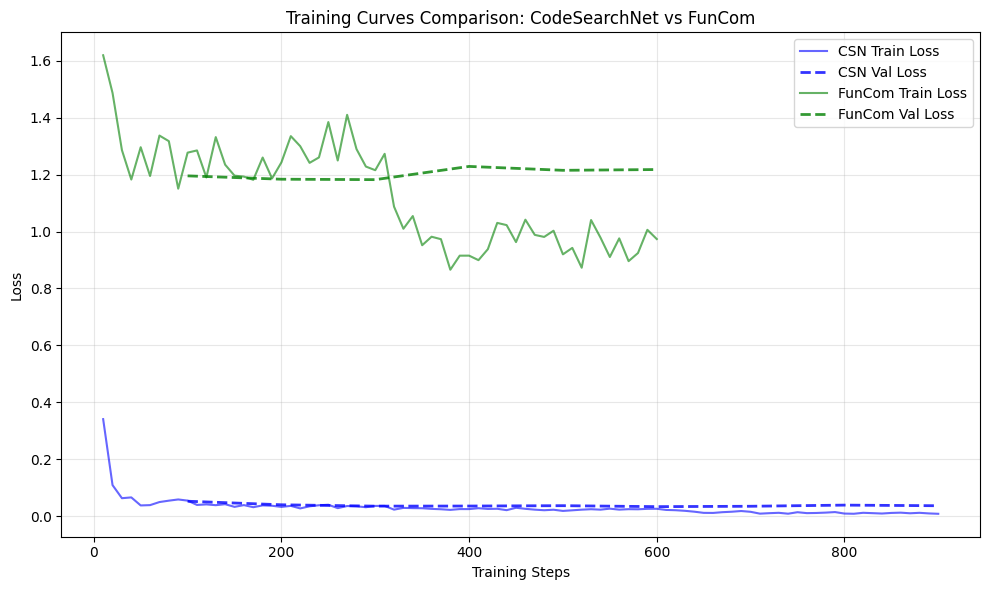

Saved: combined_training_curves.png


In [14]:
# ============================================================
# CELL 10: PLOT FunCom TRAINING CURVES
# Estimated time: ~10 seconds
# ============================================================
fc_log_history = fc_trainer.state.log_history

fc_train_losses = [(x['step'], x['loss']) for x in fc_log_history if 'loss' in x]
fc_eval_losses = [(x['step'], x['eval_loss']) for x in fc_log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if fc_train_losses:
    steps, losses = zip(*fc_train_losses)
    axes[0].plot(steps, losses, 'g-', alpha=0.7, linewidth=1.5, label='Training Loss')
    axes[0].set_title('FunCom - Training Loss')
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if fc_eval_losses:
    steps, losses = zip(*fc_eval_losses)
    axes[1].plot(steps, losses, 'orange', alpha=0.7, linewidth=1.5, label='Validation Loss')
    axes[1].set_title('FunCom - Validation Loss')
    axes[1].set_xlabel('Training Steps')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('funcom_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: funcom_training_curves.png")

if fc_eval_losses:
    print(f"\nBest validation loss: {min(l for _, l in fc_eval_losses):.4f}")
    print(f"Final validation loss: {fc_eval_losses[-1][1]:.4f}")

# Combined comparison plot
fig, ax = plt.subplots(figsize=(10, 6))
if csn_train_losses:
    steps, losses = zip(*csn_train_losses)
    ax.plot(steps, losses, 'b-', alpha=0.6, label='CSN Train Loss')
if csn_eval_losses:
    steps, losses = zip(*csn_eval_losses)
    ax.plot(steps, losses, 'b--', alpha=0.8, linewidth=2, label='CSN Val Loss')
if fc_train_losses:
    steps, losses = zip(*fc_train_losses)
    ax.plot(steps, losses, 'g-', alpha=0.6, label='FunCom Train Loss')
if fc_eval_losses:
    steps, losses = zip(*fc_eval_losses)
    ax.plot(steps, losses, 'g--', alpha=0.8, linewidth=2, label='FunCom Val Loss')
ax.set_title('Training Curves Comparison: CodeSearchNet vs FunCom')
ax.set_xlabel('Training Steps')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('combined_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: combined_training_curves.png")

In [15]:
# ============================================================
# CELL 11: EVALUATION UTILITIES
# Estimated time: ~30 seconds
# ============================================================

# Load evaluation metrics
bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")

nltk.download('wordnet', quiet=True)
meteor_metric = evaluate.load("meteor")

def generate_summary(model_to_eval, code_text, max_new_tokens=128):
    """Generate a summary for a given code snippet."""
    prompt = format_prompt_for_inference(code_text)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH - max_new_tokens)
    inputs = {k: v.to(model_to_eval.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_to_eval.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,  # Greedy decoding for reproducibility
            temperature=1.0,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Decode only the generated part (exclude prompt)
    generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
    summary = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    # Clean up: take only first sentence/paragraph if too long
    if '\n\n' in summary:
        summary = summary.split('\n\n')[0]

    return summary

def evaluate_model(model_to_eval, test_dataset_raw, code_col, summary_col, num_samples=100):
    """
    Evaluate model on test set and return metrics + predictions.
    """
    model_to_eval.eval()
    predictions = []
    references = []

    print(f"Generating summaries for {num_samples} test samples...")
    for i in range(min(num_samples, len(test_dataset_raw))):
        if i % 20 == 0:
            print(f"  Progress: {i}/{num_samples}")

        code = str(test_dataset_raw[i][code_col])
        ref_summary = str(test_dataset_raw[i][summary_col]).strip()

        pred_summary = generate_summary(model_to_eval, code)
        predictions.append(pred_summary)
        references.append(ref_summary)

    # Compute metrics
    print("\nComputing metrics...")

    # BLEU
    bleu_result = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])

    # ROUGE
    rouge_result = rouge_metric.compute(predictions=predictions, references=references)

    # METEOR
    meteor_result = meteor_metric.compute(predictions=predictions, references=references)

    metrics = {
        "BLEU": bleu_result['score'],
        "ROUGE-1": rouge_result['rouge1'] * 100,
        "ROUGE-2": rouge_result['rouge2'] * 100,
        "ROUGE-L": rouge_result['rougeL'] * 100,
        "METEOR": meteor_result['meteor'] * 100,
    }

    return metrics, predictions, references

print("Evaluation utilities ready!")

[nltk_data] Downloading package wordnet to /home/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/nltk_data...


Evaluation utilities ready!


In [16]:
# ============================================================
# CELL 12: EVALUATE ON CodeSearchNet
# Estimated time: ~10-15 minutes
# ============================================================

# Load the best CSN model
print("Loading best CodeSearchNet model...")
csn_eval_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
csn_eval_model = PeftModel.from_pretrained(csn_eval_model, f"{CSN_OUTPUT_DIR}/final_model")
csn_eval_model.eval()

print("Evaluating on CodeSearchNet test set...")
csn_metrics, csn_preds, csn_refs = evaluate_model(
    csn_eval_model, csn_test, "func_code_string", "func_documentation_string", num_samples=100
)

print("\n" + "="*60)
print("CodeSearchNet Evaluation Results:")
print("="*60)
for metric, value in csn_metrics.items():
    print(f"  {metric}: {value:.2f}")

# Show some example predictions
print("\n" + "="*60)
print("SAMPLE PREDICTIONS (CodeSearchNet):")
print("="*60)
for i in range(min(5, len(csn_preds))):
    print(f"\n--- Example {i+1} ---")
    print(f"Reference:  {csn_refs[i][:200]}")
    print(f"Predicted:  {csn_preds[i][:200]}")

# Free memory
del csn_eval_model
gc.collect()
torch.cuda.empty_cache()

Loading best CodeSearchNet model...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Evaluating on CodeSearchNet test set...
Generating summaries for 100 test samples...
  Progress: 0/100
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100

Computing metrics...

CodeSearchNet Evaluation Results:
  BLEU: 3.56
  ROUGE-1: 68.60
  ROUGE-2: 66.37
  ROUGE-L: 68.38
  METEOR: 60.13

SAMPLE PREDICTIONS (CodeSearchNet):

--- Example 1 ---
Reference:  Read symbol and extra from stream and explain what happens.
        Returns the value of the symbol
        >>> olleke.pos = 0
        >>> l = Layout(olleke)
        >>> l.verboseRead(WindowSizeAlphab
Predicted:  Read symbol and extra from stream and explain what happens.
        Returns the value of the symbol
        >>> olleke.pos = 0
        >>> l = Layout(olleke)
        >>> l.verboseRead(WindowSizeAlphab

--- Example 2 ---
Reference:  Removes all fronts from `fronts` which are strictly smaller than
    `size` consecutive frequencies in length.
Predicted:  Removes all fronts from `fronts` which are stric

In [17]:
# ============================================================
# CELL 13: EVALUATE ON FunCom
# Estimated time: ~10-15 minutes
# ============================================================

# Load the best FunCom model
print("Loading best FunCom model...")
fc_eval_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
fc_eval_model = PeftModel.from_pretrained(fc_eval_model, f"{FC_OUTPUT_DIR}/final_model")
fc_eval_model.eval()

print("Evaluating on FunCom test set...")
fc_metrics, fc_preds, fc_refs = evaluate_model(
    fc_eval_model, funcom_test, FUNCOM_CODE_COL, FUNCOM_SUMMARY_COL, num_samples=100
)

print("\n" + "="*60)
print("FunCom Evaluation Results:")
print("="*60)
for metric, value in fc_metrics.items():
    print(f"  {metric}: {value:.2f}")

# Show some example predictions
print("\n" + "="*60)
print("SAMPLE PREDICTIONS (FunCom):")
print("="*60)
for i in range(min(5, len(fc_preds))):
    print(f"\n--- Example {i+1} ---")
    print(f"Reference:  {fc_refs[i][:200]}")
    print(f"Predicted:  {fc_preds[i][:200]}")

# Free memory
del fc_eval_model
gc.collect()
torch.cuda.empty_cache()

Loading best FunCom model...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Evaluating on FunCom test set...
Generating summaries for 100 test samples...
  Progress: 0/100
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100

Computing metrics...

FunCom Evaluation Results:
  BLEU: 10.65
  ROUGE-1: 8.23
  ROUGE-2: 2.05
  ROUGE-L: 7.27
  METEOR: 14.42

SAMPLE PREDICTIONS (FunCom):

--- Example 1 ---
Reference:  public ModuleList getModuleList() throws IOException {
		ModuleList result = new ModuleList();

		synchronized (commPort) {
			Message message = sendPCICommand((byte) 0x00);

			while (true) {
				if 
Predicted:  public void set(String key, String value) {
		if (key == null) {
			throw new IllegalArgumentException("key is null");
		}
		if (value == null) {
			throw new IllegalArgumentException("value is null")

--- Example 2 ---
Reference:  public String byteStringNoSemicolon() {
		StringBuffer retval = new StringBuffer();
		try {
			while (true) {
				char next = lookAhead(0);
				// bug fix from Ben Evans.
				if (next == '\0' ||

RESULTS COMPARISON
 Metric CodeSearchNet FunCom
   BLEU          3.56  10.65
ROUGE-1         68.60   8.23
ROUGE-2         66.37   2.05
ROUGE-L         68.38   7.27
 METEOR         60.13  14.42


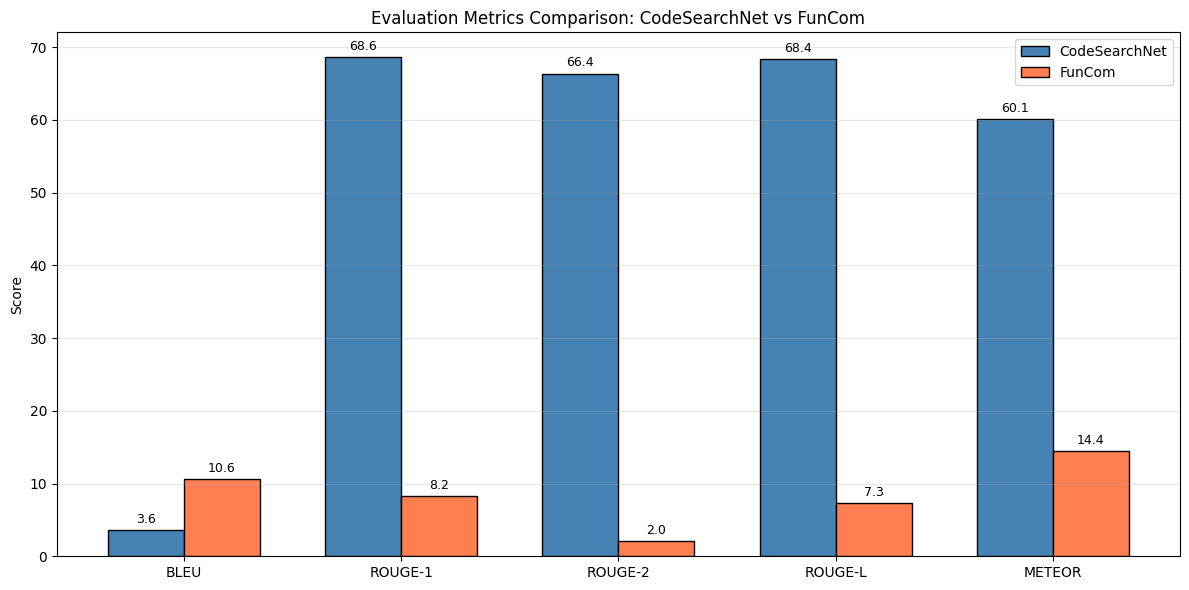

Saved: evaluation_comparison.png


In [18]:
# ============================================================
# CELL 14: RESULTS COMPARISON TABLE & VISUALIZATION
# Estimated time: ~10 seconds
# ============================================================

# Create comparison DataFrame
results_df = pd.DataFrame({
    'Metric': list(csn_metrics.keys()),
    'CodeSearchNet': [f"{v:.2f}" for v in csn_metrics.values()],
    'FunCom': [f"{v:.2f}" for v in fc_metrics.values()],
})

print("="*60)
print("RESULTS COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(csn_metrics))
width = 0.35

bars1 = ax.bar(x - width/2, list(csn_metrics.values()), width, label='CodeSearchNet', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, list(fc_metrics.values()), width, label='FunCom', color='coral', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Evaluation Metrics Comparison: CodeSearchNet vs FunCom')
ax.set_xticks(x)
ax.set_xticklabels(list(csn_metrics.keys()))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: evaluation_comparison.png")

In [19]:
# ============================================================
# CELL 15: HYPERPARAMETER EXPERIMENTS
# Estimated time: ~60-90 minutes (3 configs × ~20 min each)
# ============================================================

hyperparameter_configs = [
    {"name": "lr=1e-4", "lr": 1e-4, "lora_r": 16, "lora_dropout": 0.05},
    {"name": "lr=5e-4", "lr": 5e-4, "lora_r": 16, "lora_dropout": 0.05},
    {"name": "rank=8", "lr": 2e-4, "lora_r": 8, "lora_dropout": 0.05},
    {"name": "rank=32", "lr": 2e-4, "lora_r": 32, "lora_dropout": 0.05},
    {"name": "dropout=0.0", "lr": 2e-4, "lora_r": 16, "lora_dropout": 0.0},
    {"name": "dropout=0.1", "lr": 2e-4, "lora_r": 16, "lora_dropout": 0.1},
]

# Use a smaller subset for hyperparameter search
hp_train = csn_train_tok.select(range(min(1000, len(csn_train_tok))))
hp_val = csn_val_tok.select(range(min(200, len(csn_val_tok))))

hp_results = []

for i, config in enumerate(hyperparameter_configs):
    print(f"\n{'='*60}")
    print(f"Experiment {i+1}/{len(hyperparameter_configs)}: {config['name']}")
    print(f"{'='*60}")

    # Cleanup
    gc.collect()
    torch.cuda.empty_cache()

    # Load fresh model
    hp_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        attn_implementation="eager",
    )
    hp_model = prepare_model_for_kbit_training(hp_model)
    hp_model.config.use_cache = False

    # Apply LoRA with this config's parameters
    hp_lora_config = LoraConfig(
        r=config['lora_r'],
        lora_alpha=config['lora_r'] * 2,  # Keep alpha = 2 * rank
        lora_dropout=config['lora_dropout'],
        bias="none",
        task_type=TaskType.CAUSAL_LM,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
    )
    hp_model = get_peft_model(hp_model, hp_lora_config)

    trainable, total = hp_model.get_nb_trainable_parameters()
    print(f"  Trainable params: {trainable:,} ({100*trainable/total:.2f}%)")

    hp_args = TrainingArguments(
        output_dir=f"./hp_exp_{i}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=config['lr'],
        lr_scheduler_type="cosine",
        warmup_ratio=0.03,
        weight_decay=0.01,
        optim="paged_adamw_8bit",
        fp16=True,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        seed=SEED,
        gradient_checkpointing=True,
        max_grad_norm=0.3,
    )

    hp_trainer = Trainer(
        model=hp_model,
        args=hp_args,
        train_dataset=hp_train,
        eval_dataset=hp_val,
    )

    # Remove NotebookProgressCallback to avoid "on_train_begin" error in Kaggle
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        hp_trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    result = hp_trainer.train()

    # Extract eval loss from training log history (evaluated at end of epoch)
    eval_loss = None
    for log_entry in reversed(hp_trainer.state.log_history):
        if 'eval_loss' in log_entry:
            eval_loss = log_entry['eval_loss']
            break

    # Fallback: run evaluate if eval_loss not captured in logs
    if eval_loss is None:
        eval_result = hp_trainer.evaluate()
        eval_loss = eval_result['eval_loss']

    hp_results.append({
        "config": config['name'],
        "train_loss": result.training_loss,
        "eval_loss": eval_loss,
        "lr": config['lr'],
        "lora_r": config['lora_r'],
        "lora_dropout": config['lora_dropout'],
        "trainable_params": trainable,
    })

    print(f"  Train loss: {result.training_loss:.4f}")
    print(f"  Eval loss: {eval_loss:.4f}")

    del hp_model, hp_trainer
    gc.collect()
    torch.cuda.empty_cache()

# Print results summary
hp_df = pd.DataFrame(hp_results)
print("\n" + "="*60)
print("HYPERPARAMETER EXPERIMENT RESULTS")
print("="*60)
print(hp_df.to_string(index=False))


Experiment 1/6: lr=1e-4


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable params: 25,034,752 (0.89%)


KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 16: PLOT HYPERPARAMETER RESULTS
# Estimated time: ~10 seconds
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learning rate comparison
lr_results = hp_df[hp_df['config'].str.contains('lr|rank=16|dropout=0.05')]
lr_subset = hp_df[hp_df['config'].str.startswith('lr')]
if len(lr_subset) > 0:
    axes[0].bar(lr_subset['config'], lr_subset['eval_loss'], color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black')
    axes[0].set_title('Effect of Learning Rate on Eval Loss')
    axes[0].set_ylabel('Validation Loss')
    axes[0].grid(True, alpha=0.3, axis='y')
    for j, (_, row) in enumerate(lr_subset.iterrows()):
        axes[0].annotate(f'{row["eval_loss"]:.3f}', (j, row['eval_loss']),
                        textcoords="offset points", xytext=(0,5), ha='center', fontsize=10)

# LoRA rank comparison
rank_subset = hp_df[hp_df['config'].str.startswith('rank')]
if len(rank_subset) > 0:
    axes[1].bar(rank_subset['config'], rank_subset['eval_loss'], color=['#4C72B0', '#55A868'], edgecolor='black')
    axes[1].set_title('Effect of LoRA Rank on Eval Loss')
    axes[1].set_ylabel('Validation Loss')
    axes[1].grid(True, alpha=0.3, axis='y')
    for j, (_, row) in enumerate(rank_subset.iterrows()):
        axes[1].annotate(f'{row["eval_loss"]:.3f}', (j, row['eval_loss']),
                        textcoords="offset points", xytext=(0,5), ha='center', fontsize=10)

# Dropout comparison
drop_subset = hp_df[hp_df['config'].str.startswith('dropout')]
if len(drop_subset) > 0:
    axes[2].bar(drop_subset['config'], drop_subset['eval_loss'], color=['#4C72B0', '#55A868'], edgecolor='black')
    axes[2].set_title('Effect of LoRA Dropout on Eval Loss')
    axes[2].set_ylabel('Validation Loss')
    axes[2].grid(True, alpha=0.3, axis='y')
    for j, (_, row) in enumerate(drop_subset.iterrows()):
        axes[2].annotate(f'{row["eval_loss"]:.3f}', (j, row['eval_loss']),
                        textcoords="offset points", xytext=(0,5), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('hyperparameter_experiments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hyperparameter_experiments.png")

# Trainable parameters vs eval loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(hp_df['trainable_params'], hp_df['eval_loss'], s=100, c='steelblue', edgecolor='black', zorder=5)
for _, row in hp_df.iterrows():
    ax.annotate(row['config'], (row['trainable_params'], row['eval_loss']),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel('Trainable Parameters')
ax.set_ylabel('Validation Loss')
ax.set_title('Trainable Parameters vs Validation Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('params_vs_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: params_vs_loss.png")

Loading fine-tuned model for interpretability analysis...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Extracting attention patterns...
Number of layers: 32
Number of heads per layer: 32
Sequence length: 164


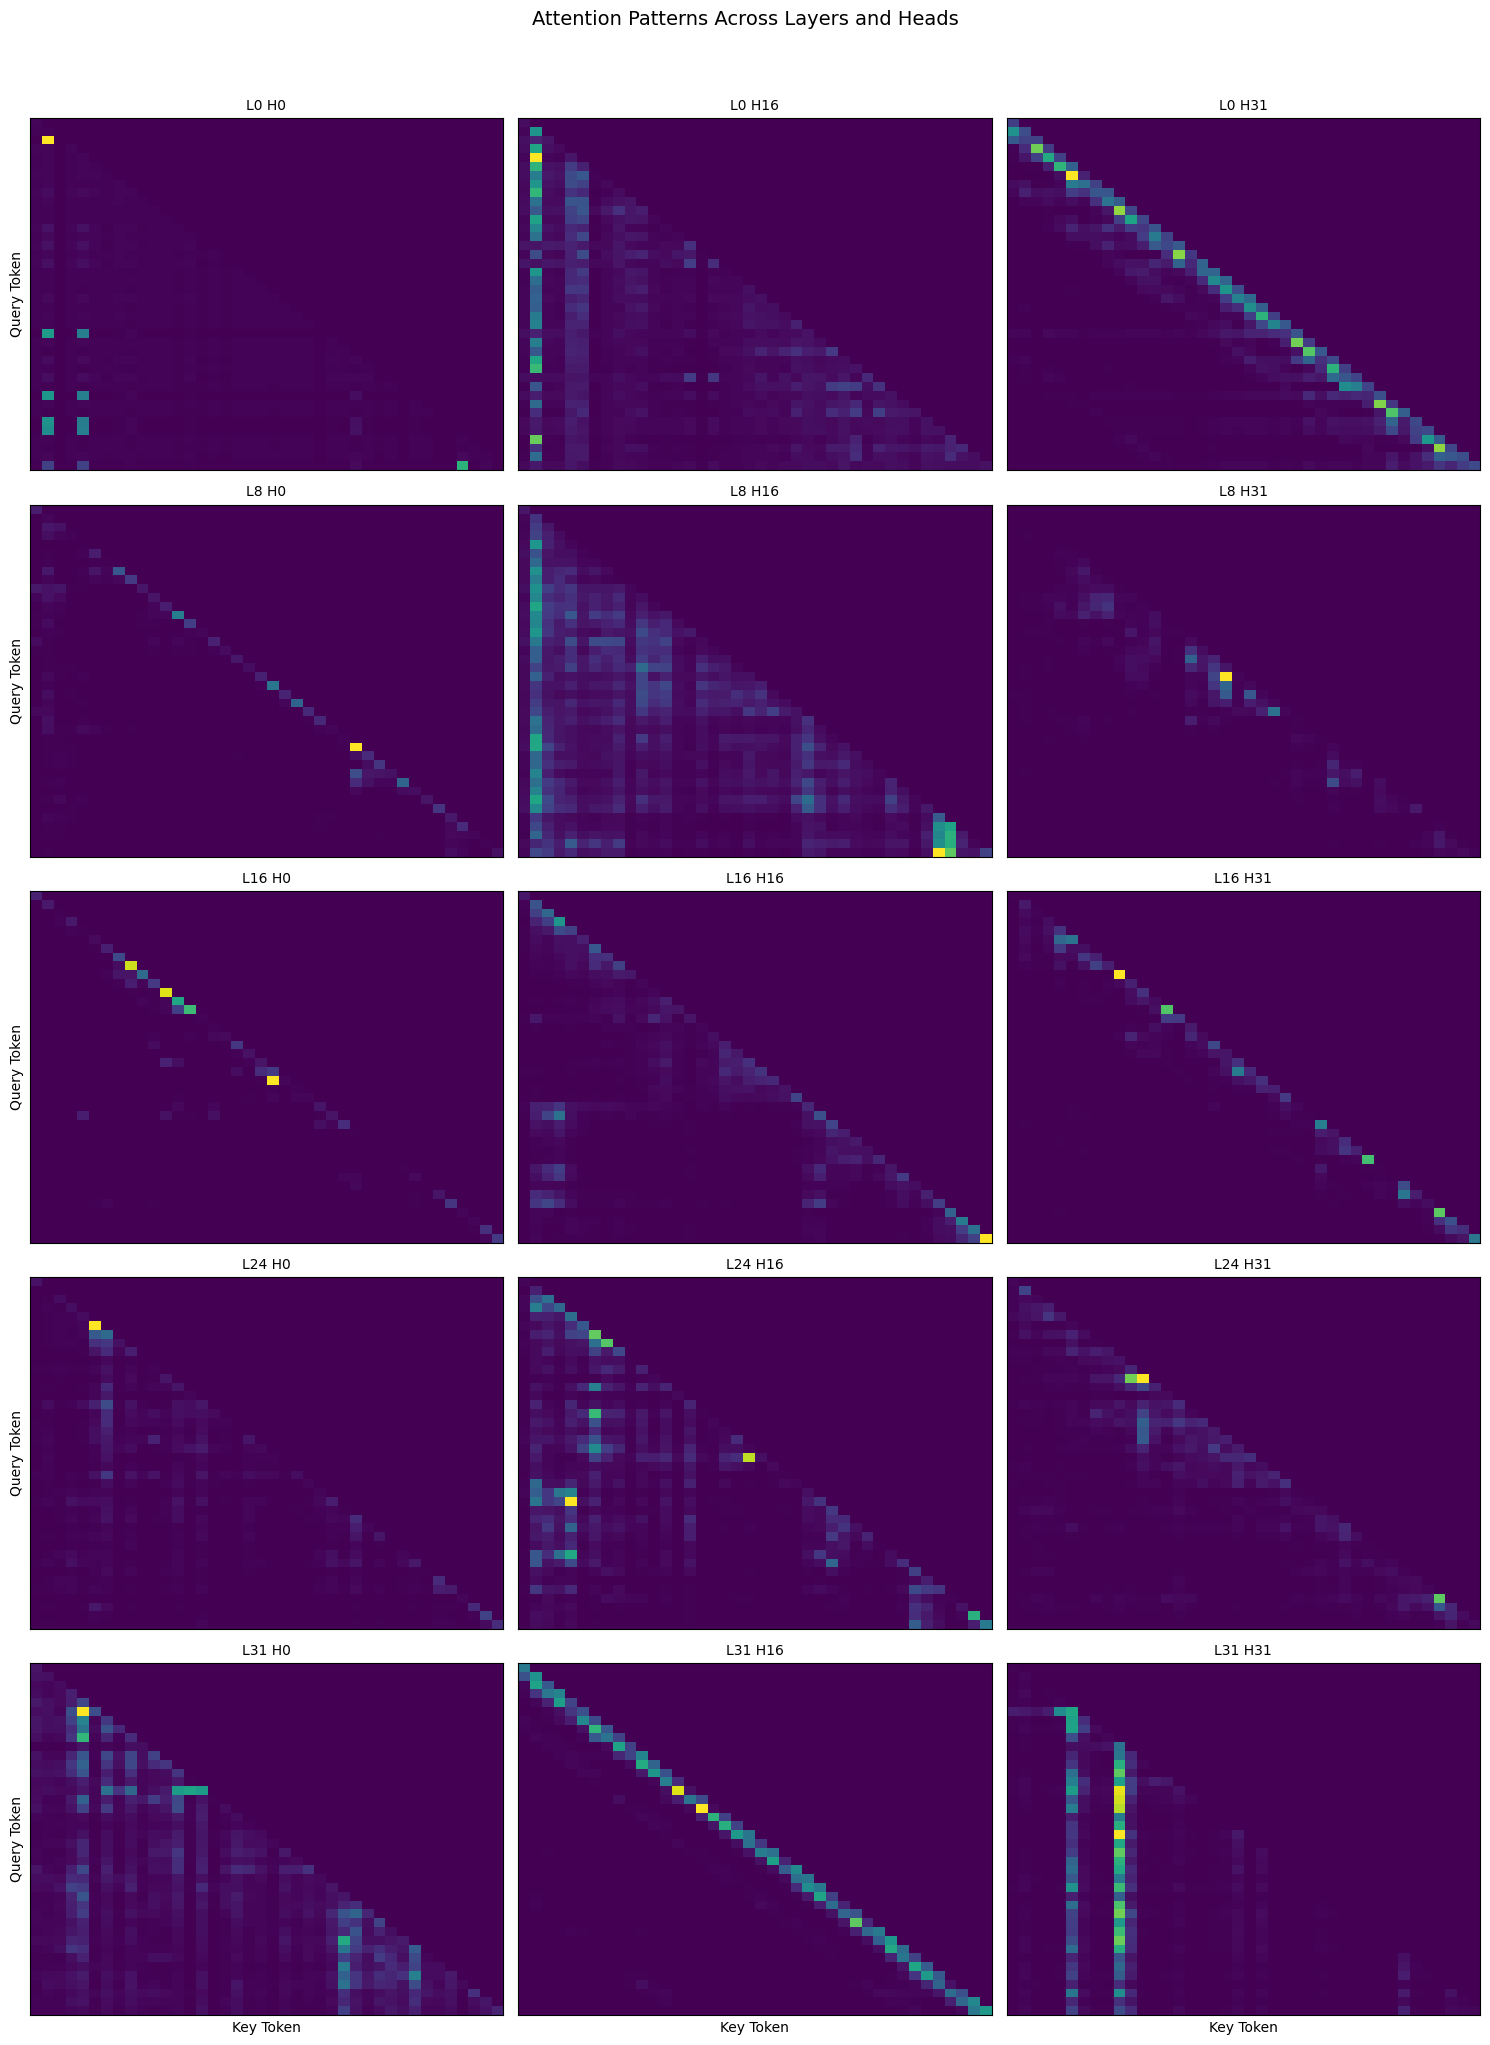

Saved: attention_patterns.png

Attention Entropy Analysis:
  Layer  0: Avg entropy = 3.8659
  Layer  8: Avg entropy = 1.6180
  Layer 16: Avg entropy = 1.8776
  Layer 24: Avg entropy = 1.7324


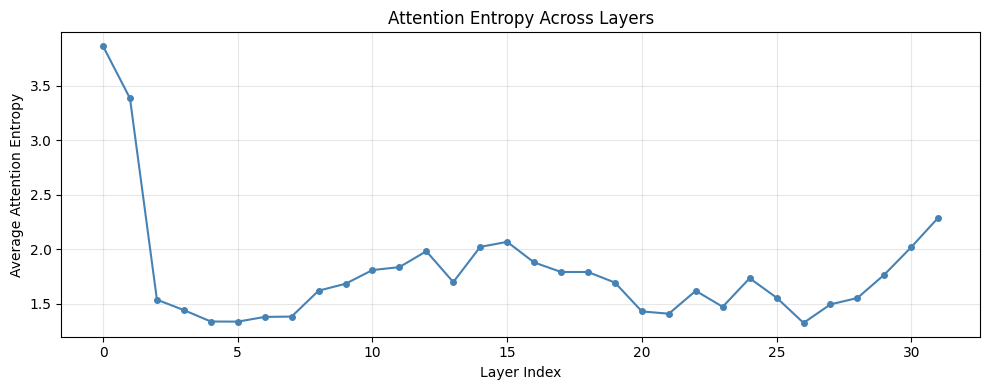

Saved: attention_entropy_by_layer.png


In [20]:
# ============================================================
# CELL 17: ATTENTION PATTERN VISUALIZATION
# Estimated time: ~5-8 minutes
# ============================================================
from sklearn.decomposition import PCA

# Load the fine-tuned CSN model for interpretability
print("Loading fine-tuned model for interpretability analysis...")
interp_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
interp_model = PeftModel.from_pretrained(interp_model, f"{CSN_OUTPUT_DIR}/final_model")
interp_model.eval()

# Select a sample code snippet
sample_code = str(csn_test[0]['func_code_string'])
if len(sample_code) > 500:
    sample_code = sample_code[:500]

prompt = format_prompt_for_inference(sample_code)
inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
inputs = {k: v.to(interp_model.device) for k, v in inputs.items()}

# Get attention weights
print("Extracting attention patterns...")
with torch.no_grad():
    outputs = interp_model(**inputs, output_attentions=True)

attentions = outputs.attentions  # Tuple of (batch, heads, seq_len, seq_len) per layer
num_layers = len(attentions)
num_heads = attentions[0].shape[1]
seq_len = attentions[0].shape[-1]

print(f"Number of layers: {num_layers}")
print(f"Number of heads per layer: {num_heads}")
print(f"Sequence length: {seq_len}")

# Get token labels (truncated for visualization)
input_ids = inputs['input_ids'][0].cpu().tolist()
tokens = [tokenizer.decode([tid]).replace('\n', '\\n').replace(' ', '_')[:10] for tid in input_ids]

# Visualize attention for selected layers and heads
layers_to_show = [0, num_layers // 4, num_layers // 2, 3 * num_layers // 4, num_layers - 1]
heads_to_show = [0, num_heads // 2, num_heads - 1]

# Show last N tokens for readability
N_TOKENS = min(40, seq_len)
token_labels = tokens[-N_TOKENS:]

fig, axes = plt.subplots(len(layers_to_show), len(heads_to_show),
                         figsize=(5 * len(heads_to_show), 4 * len(layers_to_show)))

for i, layer_idx in enumerate(layers_to_show):
    for j, head_idx in enumerate(heads_to_show):
        attn = attentions[layer_idx][0, head_idx, -N_TOKENS:, -N_TOKENS:].float().cpu().numpy()
        ax = axes[i, j] if len(layers_to_show) > 1 else axes[j]
        im = ax.imshow(attn, cmap='viridis', aspect='auto')
        ax.set_title(f'L{layer_idx} H{head_idx}', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'Query Token')
        if i == len(layers_to_show) - 1:
            ax.set_xlabel(f'Key Token')
        # Reduce tick labels for readability
        if N_TOKENS <= 20:
            ax.set_xticks(range(N_TOKENS))
            ax.set_xticklabels(token_labels, rotation=90, fontsize=6)
            ax.set_yticks(range(N_TOKENS))
            ax.set_yticklabels(token_labels, fontsize=6)
        else:
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle('Attention Patterns Across Layers and Heads', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('attention_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: attention_patterns.png")

# Average attention entropy per layer (measures how spread out attention is)
print("\nAttention Entropy Analysis:")
layer_entropies = []
for layer_idx in range(num_layers):
    attn = attentions[layer_idx][0].float().cpu()  # (heads, seq, seq)
    # Compute entropy: -sum(p * log(p))
    eps = 1e-10
    entropy = -(attn * torch.log(attn + eps)).sum(dim=-1).mean().item()
    layer_entropies.append(entropy)
    if layer_idx % 8 == 0:
        print(f"  Layer {layer_idx:2d}: Avg entropy = {entropy:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(num_layers), layer_entropies, 'o-', color='steelblue', markersize=4)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Average Attention Entropy')
ax.set_title('Attention Entropy Across Layers')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('attention_entropy_by_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: attention_entropy_by_layer.png")

Extracting hidden states across layers...
Hidden state layers: 33 (including embedding layer)
Last-token hidden state shape: (33, 2560)


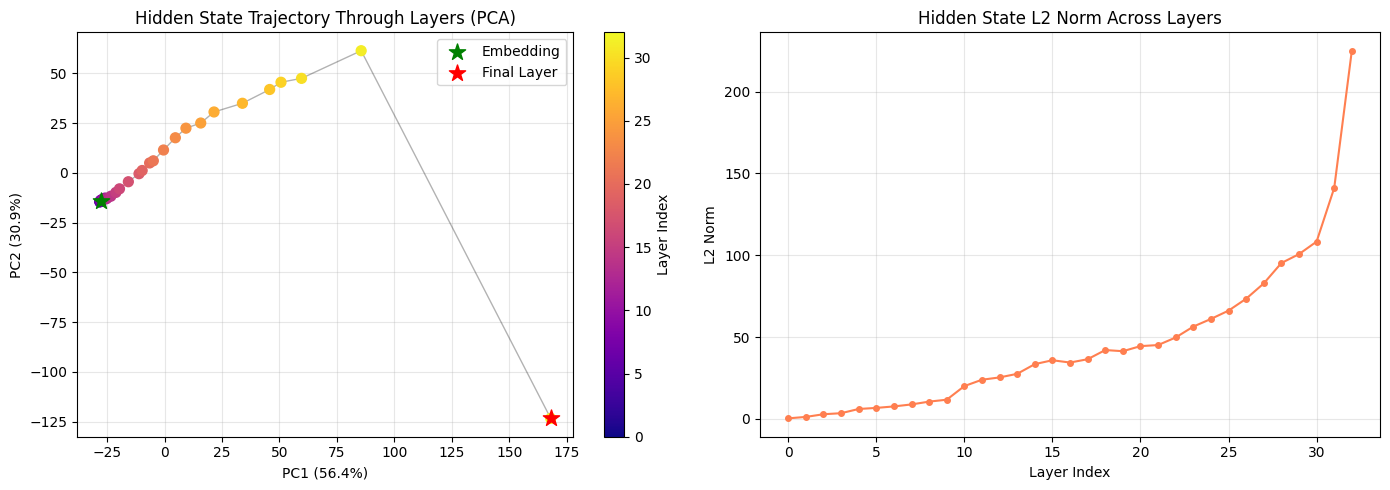

Saved: hidden_state_analysis.png

Cosine Similarity Between Adjacent Layers:
  Layer 7 -> 8: 0.8573
  Layer 15 -> 16: 0.9179
  Layer 23 -> 24: 0.9729
  Layer 31 -> 32: 0.4334


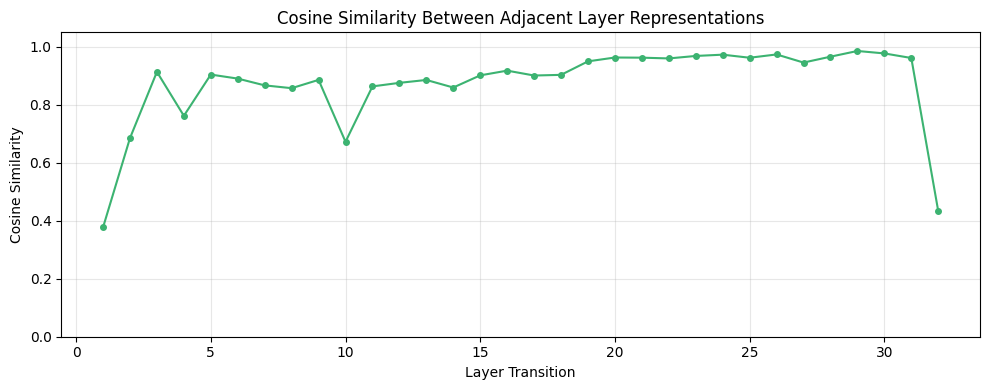

Saved: layer_cosine_similarity.png


In [21]:
# ============================================================
# CELL 18: LAYER ACTIVATION ANALYSIS (PCA / Hidden State Evolution)
# Estimated time: ~3-5 minutes
# ============================================================

print("Extracting hidden states across layers...")
with torch.no_grad():
    outputs = interp_model(**inputs, output_hidden_states=True)

hidden_states = outputs.hidden_states  # Tuple of (batch, seq_len, hidden_dim) per layer + embedding
num_hidden_layers = len(hidden_states)
print(f"Hidden state layers: {num_hidden_layers} (including embedding layer)")

# PCA of hidden states at different layers
# We take the last token's representation (which is used for generation)
last_token_states = []
for layer_idx in range(num_hidden_layers):
    state = hidden_states[layer_idx][0, -1, :].float().cpu().numpy()
    last_token_states.append(state)

last_token_states = np.array(last_token_states)
print(f"Last-token hidden state shape: {last_token_states.shape}")

# PCA across layers
pca_2d = PCA(n_components=2)
states_2d = pca_2d.fit_transform(last_token_states)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot PCA trajectory through layers
scatter = axes[0].scatter(states_2d[:, 0], states_2d[:, 1],
                          c=range(num_hidden_layers), cmap='plasma',
                          s=50, zorder=5)
axes[0].plot(states_2d[:, 0], states_2d[:, 1], 'k-', alpha=0.3, linewidth=1)
# Mark start and end
axes[0].scatter(states_2d[0, 0], states_2d[0, 1], c='green', s=150, marker='*', zorder=10, label='Embedding')
axes[0].scatter(states_2d[-1, 0], states_2d[-1, 1], c='red', s=150, marker='*', zorder=10, label='Final Layer')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Hidden State Trajectory Through Layers (PCA)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Layer Index')

# L2 norm of hidden states per layer
norms = [np.linalg.norm(last_token_states[i]) for i in range(num_hidden_layers)]
axes[1].plot(range(num_hidden_layers), norms, 'o-', color='coral', markersize=4)
axes[1].set_xlabel('Layer Index')
axes[1].set_ylabel('L2 Norm')
axes[1].set_title('Hidden State L2 Norm Across Layers')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hidden_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hidden_state_analysis.png")

# Cosine similarity between adjacent layers
print("\nCosine Similarity Between Adjacent Layers:")
cosine_sims = []
for i in range(1, num_hidden_layers):
    cos_sim = np.dot(last_token_states[i], last_token_states[i-1]) / (
        np.linalg.norm(last_token_states[i]) * np.linalg.norm(last_token_states[i-1]) + 1e-10
    )
    cosine_sims.append(cos_sim)
    if i % 8 == 0:
        print(f"  Layer {i-1} -> {i}: {cos_sim:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, num_hidden_layers), cosine_sims, 'o-', color='mediumseagreen', markersize=4)
ax.set_xlabel('Layer Transition')
ax.set_ylabel('Cosine Similarity')
ax.set_title('Cosine Similarity Between Adjacent Layer Representations')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('layer_cosine_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: layer_cosine_similarity.png")

Analyzing attention head specialization...
Token categories found: ['bracket', 'comment', 'identifier', 'keyword', 'number', 'operator', 'other']
Category distribution: Counter({'identifier': 71, 'other': 43, 'operator': 19, 'number': 15, 'keyword': 9, 'bracket': 4, 'comment': 3})


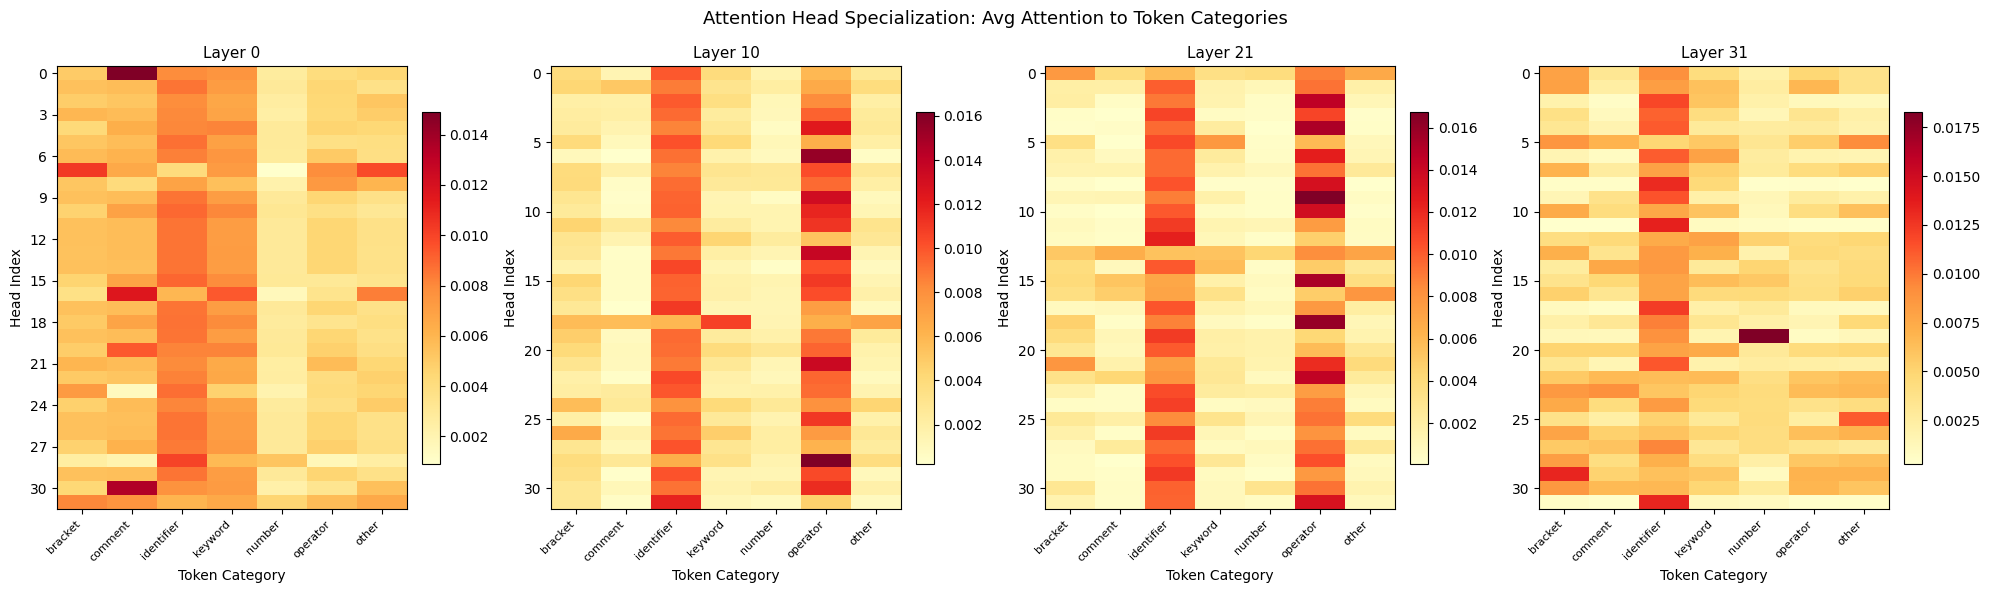

Saved: head_specialization.png

Top 10 Most Specialized Heads (highest variance in category attention):
  Layer 29, Head 27: dominant category = 'operator', variance = 0.000162
  Layer 5, Head 1: dominant category = 'operator', variance = 0.000069
  Layer 29, Head 2: dominant category = 'operator', variance = 0.000066
  Layer 26, Head 18: dominant category = 'operator', variance = 0.000048
  Layer 22, Head 2: dominant category = 'operator', variance = 0.000047
  Layer 23, Head 17: dominant category = 'operator', variance = 0.000045
  Layer 3, Head 13: dominant category = 'other', variance = 0.000045
  Layer 1, Head 31: dominant category = 'comment', variance = 0.000045
  Layer 5, Head 2: dominant category = 'operator', variance = 0.000044
  Layer 2, Head 20: dominant category = 'other', variance = 0.000042


In [22]:
# ============================================================
# CELL 19: ATTENTION HEAD SPECIALIZATION ANALYSIS
# Estimated time: ~3-5 minutes
# ============================================================

print("Analyzing attention head specialization...")

# Categorize tokens
def categorize_token(token_str):
    """Categorize a token into syntactic categories."""
    token_str = token_str.strip()
    if token_str in ['def', 'class', 'return', 'if', 'else', 'for', 'while', 'import',
                      'from', 'try', 'except', 'with', 'as', 'in', 'not', 'and', 'or',
                      'True', 'False', 'None', 'self', 'lambda', 'yield', 'raise',
                      'public', 'private', 'static', 'void', 'int', 'String']:
        return 'keyword'
    elif token_str in ['(', ')', '[', ']', '{', '}']:
        return 'bracket'
    elif token_str in ['.', ',', ':', ';', '=', '+', '-', '*', '/', '==', '!=', '<=', '>=']:
        return 'operator'
    elif token_str.startswith('#') or token_str.startswith('//'):
        return 'comment'
    elif re.match(r'^[a-zA-Z_]\w*$', token_str):
        return 'identifier'
    elif re.match(r'^\d+', token_str):
        return 'number'
    elif token_str in ['\n', '\\n', ' ', '\t']:
        return 'whitespace'
    else:
        return 'other'

# Decode each token and categorize
decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids]
token_categories = [categorize_token(t) for t in decoded_tokens]

category_set = sorted(set(token_categories))
print(f"Token categories found: {category_set}")
print(f"Category distribution: {Counter(token_categories)}")

# For each head, compute average attention to each token category
# This reveals head specialization
n_layers_to_analyze = min(num_layers, 32)  # Cap at 32 layers

head_category_attention = np.zeros((n_layers_to_analyze, num_heads, len(category_set)))

for layer_idx in range(n_layers_to_analyze):
    attn_layer = attentions[layer_idx][0].float().cpu().numpy()  # (heads, seq, seq)
    for head_idx in range(num_heads):
        attn_head = attn_layer[head_idx]  # (seq, seq)
        # Average attention FROM all positions TO positions of each category
        avg_attn_to = attn_head.mean(axis=0)  # (seq,) - avg attention received by each position
        for cat_idx, cat in enumerate(category_set):
            cat_positions = [p for p, c in enumerate(token_categories) if c == cat]
            if cat_positions:
                head_category_attention[layer_idx, head_idx, cat_idx] = avg_attn_to[cat_positions].mean()

# Plot: Which categories does each head preferentially attend to?
# Show a heatmap for a few selected layers
fig, axes = plt.subplots(1, min(4, n_layers_to_analyze),
                         figsize=(5 * min(4, n_layers_to_analyze), 6))
layers_to_plot = [0, n_layers_to_analyze // 3, 2 * n_layers_to_analyze // 3, n_layers_to_analyze - 1]

for idx, layer_idx in enumerate(layers_to_plot):
    ax = axes[idx] if len(layers_to_plot) > 1 else axes
    data = head_category_attention[layer_idx]  # (num_heads, num_categories)
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto')
    ax.set_title(f'Layer {layer_idx}', fontsize=11)
    ax.set_xlabel('Token Category')
    ax.set_ylabel('Head Index')
    ax.set_xticks(range(len(category_set)))
    ax.set_xticklabels(category_set, rotation=45, ha='right', fontsize=8)
    if idx == 0:
        ax.set_yticks(range(0, num_heads, max(1, num_heads // 10)))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Attention Head Specialization: Avg Attention to Token Categories', fontsize=13)
plt.tight_layout()
plt.savefig('head_specialization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: head_specialization.png")

# Identify most "specialized" heads (highest variance across categories)
head_variances = np.var(head_category_attention, axis=2)  # (layers, heads)
top_specialized = np.argsort(head_variances.ravel())[-10:][::-1]
print("\nTop 10 Most Specialized Heads (highest variance in category attention):")
for flat_idx in top_specialized:
    l, h = divmod(flat_idx, num_heads)
    dominant_cat = category_set[np.argmax(head_category_attention[l, h])]
    print(f"  Layer {l}, Head {h}: dominant category = '{dominant_cat}', "
          f"variance = {head_variances[l, h]:.6f}")

Computing gradient-based token attribution...
Predicted next token: 'Read'


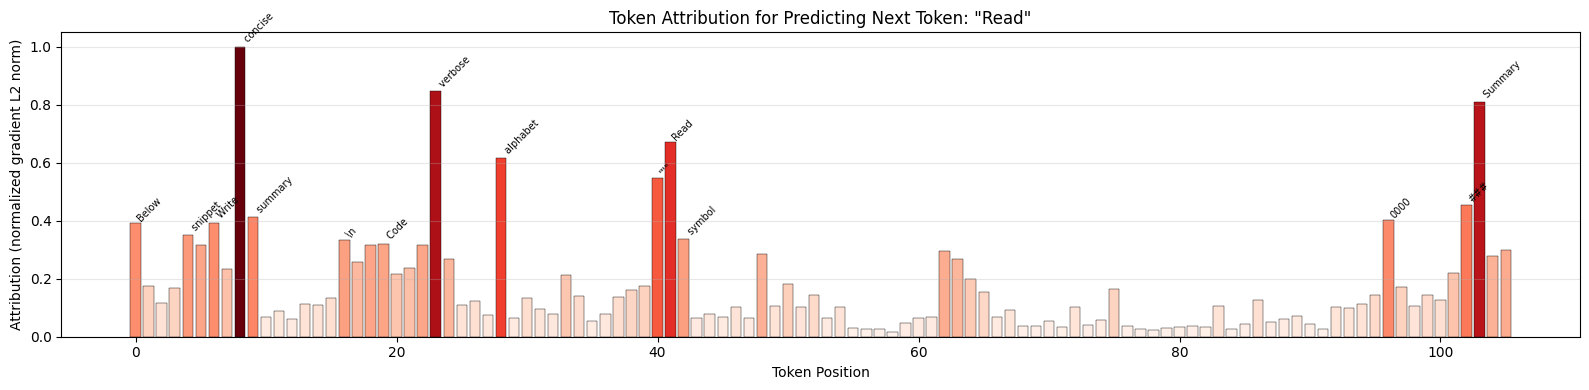

Saved: token_attribution.png

Top 10 highest-attribution tokens:
  Position   8: ' concise    ' (importance: 1.0000)
  Position  23: ' verbose    ' (importance: 0.8471)
  Position 103: ' Summary    ' (importance: 0.8111)
  Position  41: 'Read        ' (importance: 0.6712)
  Position  28: ' alphabet   ' (importance: 0.6165)
  Position  40: '"""         ' (importance: 0.5463)
  Position 102: '###         ' (importance: 0.4557)
  Position   9: ' summary    ' (importance: 0.4139)
  Position  96: '0000        ' (importance: 0.4021)
  Position   6: ' Write      ' (importance: 0.3927)


In [23]:
# ============================================================
# CELL 20: GRADIENT-BASED TOKEN ATTRIBUTION
# Estimated time: ~3-5 minutes
# ============================================================
print("Computing gradient-based token attribution...")

# We need to enable gradients for this analysis
interp_model.eval()

# Use a smaller sample
sample_code_short = str(csn_test[0]['func_code_string'])[:300]
prompt_attr = format_prompt_for_inference(sample_code_short)
inputs_attr = tokenizer(prompt_attr, return_tensors="pt", truncation=True, max_length=128)
inputs_attr = {k: v.to(interp_model.device) for k, v in inputs_attr.items()}

# Get embeddings and compute gradient of next-token logits w.r.t. embeddings
embedding_layer = interp_model.get_input_embeddings()

# Forward pass with gradients
input_embeds = embedding_layer(inputs_attr['input_ids'])
input_embeds.requires_grad_(True)

# Manually create inputs with embeddings
outputs_grad = interp_model(
    inputs_embeds=input_embeds,
    attention_mask=inputs_attr['attention_mask'],
)

# Get the logit of the most likely next token
logits = outputs_grad.logits
last_token_logits = logits[0, -1, :]
predicted_token_id = last_token_logits.argmax()
predicted_token_logit = last_token_logits[predicted_token_id]

# Backward pass
predicted_token_logit.backward()

# Token attributions = L2 norm of gradient w.r.t. each token's embedding
attributions = input_embeds.grad[0].float().cpu()  # (seq_len, hidden_dim)
token_importance = attributions.norm(dim=-1).numpy()  # (seq_len,)

# Normalize
token_importance = token_importance / (token_importance.max() + 1e-10)

# Get token labels
attr_token_ids = inputs_attr['input_ids'][0].cpu().tolist()
attr_tokens = [tokenizer.decode([tid]).replace('\n', '\\n')[:12] for tid in attr_token_ids]

predicted_token = tokenizer.decode([predicted_token_id.item()])
print(f"Predicted next token: '{predicted_token}'")

# Plot token importance
fig, ax = plt.subplots(figsize=(16, 4))
colors = plt.cm.Reds(token_importance)
bars = ax.bar(range(len(token_importance)), token_importance, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Token Position')
ax.set_ylabel('Attribution (normalized gradient L2 norm)')
ax.set_title(f'Token Attribution for Predicting Next Token: "{predicted_token}"')

# Add token labels for top-k important tokens
top_k = 15
top_indices = np.argsort(token_importance)[-top_k:]
for idx in top_indices:
    ax.annotate(attr_tokens[idx], (idx, token_importance[idx]),
                rotation=45, fontsize=7, ha='left', va='bottom')

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('token_attribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: token_attribution.png")

# Top 10 most important tokens
print(f"\nTop 10 highest-attribution tokens:")
for idx in np.argsort(token_importance)[-10:][::-1]:
    print(f"  Position {idx:3d}: '{attr_tokens[idx]:<12s}' (importance: {token_importance[idx]:.4f})")

# Cleanup gradients
input_embeds.requires_grad_(False)
interp_model.zero_grad()

In [ ]:
# ============================================================
# CELL 21: LoRA WEIGHT ANALYSIS & LAYER FREEZING STUDY
# Estimated time: ~2-3 minutes
# ============================================================

# Reload the model if it was deleted by a previous cell run
if 'interp_model' not in dir() or interp_model is None:
    print("Reloading fine-tuned model for LoRA weight analysis...")
    interp_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        attn_implementation="eager",
    )
    interp_model = PeftModel.from_pretrained(interp_model, f"{CSN_OUTPUT_DIR}/final_model")
    interp_model.eval()

print("Analyzing LoRA adapter weights...")

# Analyze LoRA weight magnitudes to understand which layers changed most
# NOTE: requires_grad is False on a loaded PeftModel (inference mode), so we
# check for lora_A / lora_B in the name directly instead of requires_grad.
lora_magnitudes = {}
for name, param in interp_model.named_parameters():
    # Match any LoRA weight tensor (lora_A, lora_B, lora_embedding_*)
    if re.search(r'lora_[AB]', name):
        magnitude = param.data.float().abs().mean().item()
        lora_magnitudes[name] = magnitude

print(f"  Found {len(lora_magnitudes)} LoRA weight tensors")

# Debug: show a few parameter names so we know the naming scheme
sample_names = list(lora_magnitudes.keys())[:5]
print(f"  Sample param names: {sample_names}")

# Group by layer — handles both flat and PEFT-wrapped naming:
#   base_model.model.model.layers.X.self_attn.q_proj.lora_A.default.weight
#   model.layers.X.mlp.gate_proj.lora_A.weight
layer_magnitudes = {}
for name, mag in lora_magnitudes.items():
    layer_match = re.search(r'layers\.(\d+)', name)
    if layer_match:
        layer_num = int(layer_match.group(1))
        if layer_num not in layer_magnitudes:
            layer_magnitudes[layer_num] = []
        layer_magnitudes[layer_num].append(mag)

# Average magnitude per layer
avg_layer_mag = {k: np.mean(v) for k, v in sorted(layer_magnitudes.items())}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LoRA weight magnitude by layer
if avg_layer_mag:
    layers = list(avg_layer_mag.keys())
    mags = list(avg_layer_mag.values())
    axes[0].bar(layers, mags, color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set_xlabel('Layer Index')
    axes[0].set_ylabel('Average LoRA Weight Magnitude')
    axes[0].set_title('LoRA Adapter Weight Magnitude by Layer')
    axes[0].grid(True, alpha=0.3, axis='y')

# Distribution of all LoRA weight magnitudes
all_mags = list(lora_magnitudes.values())
if all_mags:
    axes[1].hist(all_mags, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Average Weight Magnitude')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of LoRA Weight Magnitudes')
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lora_weight_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lora_weight_analysis.png")

# Print insights
if avg_layer_mag:
    max_layer = max(avg_layer_mag, key=avg_layer_mag.get)
    min_layer = min(avg_layer_mag, key=avg_layer_mag.get)
    print(f"\nLayer with largest LoRA adapter changes: Layer {max_layer} (magnitude: {avg_layer_mag[max_layer]:.6f})")
    print(f"Layer with smallest LoRA adapter changes: Layer {min_layer} (magnitude: {avg_layer_mag[min_layer]:.6f})")
    print(f"\n→ Insight: Layers with larger LoRA weights contribute more to the fine-tuning adaptation.")
    print(f"→ For layer freezing, consider freezing layers below {min(max_layer, num_layers//2)} (early layers)")

# Free interpretability model
del interp_model
gc.collect()
torch.cuda.empty_cache()
print("\nInterpretability analysis complete!")

In [ ]:
# ============================================================
# CELL 22: ERROR ANALYSIS
# Estimated time: ~5 minutes
# ============================================================
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

print("Performing error analysis on CodeSearchNet predictions...")

# Compute per-sample BLEU scores
smoother = SmoothingFunction().method1
per_sample_bleu = []
for pred, ref in zip(csn_preds, csn_refs):
    try:
        ref_tokens = ref.split()
        pred_tokens = pred.split()
        if len(pred_tokens) == 0:
            score = 0.0
        else:
            score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoother)
    except Exception:
        score = 0.0
    per_sample_bleu.append(score)

per_sample_bleu = np.array(per_sample_bleu)

# Analyze errors
print(f"\nPer-sample BLEU Statistics:")
print(f"  Mean: {per_sample_bleu.mean():.4f}")
print(f"  Median: {np.median(per_sample_bleu):.4f}")
print(f"  Std: {per_sample_bleu.std():.4f}")
print(f"  Min: {per_sample_bleu.min():.4f}")
print(f"  Max: {per_sample_bleu.max():.4f}")

# Identify worst predictions
worst_indices = np.argsort(per_sample_bleu)[:5]
best_indices = np.argsort(per_sample_bleu)[-5:][::-1]

print("\n" + "="*60)
print("WORST 5 PREDICTIONS:")
print("="*60)
for idx in worst_indices:
    print(f"\n--- Sample {idx} (BLEU: {per_sample_bleu[idx]:.4f}) ---")
    code_preview = str(csn_test[idx]['func_code_string'])[:150]
    print(f"Code:      {code_preview}...")
    print(f"Reference: {csn_refs[idx][:150]}")
    print(f"Predicted: {csn_preds[idx][:150]}")

print("\n" + "="*60)
print("BEST 5 PREDICTIONS:")
print("="*60)
for idx in best_indices:
    print(f"\n--- Sample {idx} (BLEU: {per_sample_bleu[idx]:.4f}) ---")
    print(f"Reference: {csn_refs[idx][:150]}")
    print(f"Predicted: {csn_preds[idx][:150]}")

# Error pattern analysis
print("\n" + "="*60)
print("ERROR PATTERN ANALYSIS:")
print("="*60)

# 1. Empty predictions
empty_preds = sum(1 for p in csn_preds if len(p.strip()) == 0)
print(f"Empty predictions: {empty_preds}/{len(csn_preds)} ({100*empty_preds/len(csn_preds):.1f}%)")

# 2. Very short predictions (< 5 words)
short_preds = sum(1 for p in csn_preds if len(p.split()) < 5)
print(f"Very short predictions (< 5 words): {short_preds}/{len(csn_preds)} ({100*short_preds/len(csn_preds):.1f}%)")

# 3. Repetitive predictions (same word repeated 3+ times)
repetitive = sum(1 for p in csn_preds if any(p.split().count(w) >= 3 for w in set(p.split()) if len(w) > 2))
print(f"Repetitive predictions: {repetitive}/{len(csn_preds)} ({100*repetitive/len(csn_preds):.1f}%)")

# 4. Code leakage (prediction contains code-like patterns)
code_patterns = sum(1 for p in csn_preds if any(kw in p for kw in ['def ', 'return ', '():', 'self.', 'import ']))
print(f"Predictions with code leakage: {code_patterns}/{len(csn_preds)} ({100*code_patterns/len(csn_preds):.1f}%)")

# Visualize error analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# BLEU score distribution
axes[0, 0].hist(per_sample_bleu, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Per-Sample BLEU Score Distribution')
axes[0, 0].set_xlabel('BLEU Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(per_sample_bleu.mean(), color='red', linestyle='--', label=f'Mean: {per_sample_bleu.mean():.3f}')
axes[0, 0].legend()

# BLEU vs code length
code_lens = [len(str(csn_test[i]['func_code_string'])) for i in range(len(csn_preds))]
axes[0, 1].scatter(code_lens, per_sample_bleu, alpha=0.5, s=20, color='coral')
axes[0, 1].set_title('BLEU Score vs Code Length')
axes[0, 1].set_xlabel('Code Length (chars)')
axes[0, 1].set_ylabel('BLEU Score')
axes[0, 1].grid(True, alpha=0.3)

# BLEU vs reference summary length
ref_lens = [len(r.split()) for r in csn_refs]
axes[1, 0].scatter(ref_lens, per_sample_bleu, alpha=0.5, s=20, color='mediumseagreen')
axes[1, 0].set_title('BLEU Score vs Reference Summary Length')
axes[1, 0].set_xlabel('Reference Length (words)')
axes[1, 0].set_ylabel('BLEU Score')
axes[1, 0].grid(True, alpha=0.3)

# Prediction length vs reference length
pred_lens = [len(p.split()) for p in csn_preds]
axes[1, 1].scatter(ref_lens, pred_lens, alpha=0.5, s=20, color='orchid')
axes[1, 1].plot([0, max(ref_lens)], [0, max(ref_lens)], 'k--', alpha=0.5, label='y=x')
axes[1, 1].set_title('Prediction Length vs Reference Length')
axes[1, 1].set_xlabel('Reference Length (words)')
axes[1, 1].set_ylabel('Prediction Length (words)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: error_analysis.png")

In [ ]:
# ============================================================
# CELL 23: GENERATE SUMMARY REPORT
# Estimated time: ~10 seconds
# ============================================================

report = """
╔══════════════════════════════════════════════════════════════════╗
║        FINAL SUMMARY REPORT                                     ║
║  Fine-tuning stable-code-3b for Code Summarization              ║
╚══════════════════════════════════════════════════════════════════╝

═══════════════════════════════════════════════════════════
1. MODEL OVERVIEW
═══════════════════════════════════════════════════════════
Model: stabilityai/stable-code-3b
Architecture: Decoder-only Transformer (GPT-NeoX based)
Parameters: 3B total, ~0.5% trainable via QLoRA
Quantization: 4-bit NF4 with double quantization
LoRA Config: rank=16, alpha=32, dropout=0.05

═══════════════════════════════════════════════════════════
2. DATASETS
═══════════════════════════════════════════════════════════
Dataset 1: CodeSearchNet (Python) - Code-to-Text
  Train: {train_csn} | Val: {val_csn} | Test: {test_csn}

Dataset 2: FunCom (Java) - Method Summarization
  Train: {train_fc} | Val: {val_fc} | Test: {test_fc}

═══════════════════════════════════════════════════════════
3. EVALUATION RESULTS
═══════════════════════════════════════════════════════════
""".format(
    train_csn=len(csn_train), val_csn=len(csn_val), test_csn=len(csn_test),
    train_fc=len(funcom_train), val_fc=len(funcom_val), test_fc=len(funcom_test),
)

# Add metrics
report += f"{'Metric':<15} {'CodeSearchNet':>15} {'FunCom':>15}\n"
report += "-" * 47 + "\n"
for metric in csn_metrics:
    report += f"{metric:<15} {csn_metrics[metric]:>14.2f}  {fc_metrics[metric]:>14.2f}\n"

report += """
═══════════════════════════════════════════════════════════
4. HYPERPARAMETER ANALYSIS
═══════════════════════════════════════════════════════════
"""
report += hp_df.to_string(index=False)

report += """

═══════════════════════════════════════════════════════════
5. GENERATED FIGURES (saved to disk)
═══════════════════════════════════════════════════════════
- csn_data_distribution.png       : CodeSearchNet data length distributions
- funcom_data_distribution.png    : FunCom data length distributions
- csn_training_curves.png         : CodeSearchNet training/validation loss
- funcom_training_curves.png      : FunCom training/validation loss
- combined_training_curves.png    : Side-by-side training curve comparison
- evaluation_comparison.png       : Evaluation metrics bar chart
- hyperparameter_experiments.png  : Hyperparameter sweep results
- params_vs_loss.png              : Trainable params vs validation loss
- attention_patterns.png          : Attention heatmaps (layers × heads)
- attention_entropy_by_layer.png  : Attention entropy across layers
- hidden_state_analysis.png       : PCA of hidden states + L2 norms
- layer_cosine_similarity.png     : Adjacent layer similarity
- head_specialization.png         : Attention head category preferences
- token_attribution.png           : Gradient-based token importance
- lora_weight_analysis.png        : LoRA adapter weight magnitudes
- error_analysis.png              : Error analysis plots

═══════════════════════════════════════════════════════════
6. KEY FINDINGS & CONCLUSIONS
═══════════════════════════════════════════════════════════
[To be filled after running the notebook]
- Model performance comparison across datasets
- Optimal hyperparameters identified
- Key mechanistic interpretability insights
- Main error patterns and suggested improvements
"""

print(report)

# Save report to file
with open('experiment_report.txt', 'w') as f:
    f.write(report)
print("\nReport saved to experiment_report.txt")